In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders_delivered = pd.read_csv('../data/orders_delivered_clean.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')

orders_customers = orders_delivered.merge(
    customers[['customer_id', 'customer_state']], 
    on='customer_id', how='left'
)

# 지역별 평균 carrier_delivery_time + 주문 건수
state_stats = orders_customers.groupby('customer_state').agg(
    avg_delivery=('carrier_delivery_time', 'mean'),
    order_count=('order_id', 'count')
).reset_index().sort_values('avg_delivery', ascending=False)

# 전체 평균
overall_mean = orders_customers['carrier_delivery_time'].mean()

# 전체 평균 대비 초과 시간 계산
state_stats['excess_hours'] = state_stats['avg_delivery'] - overall_mean

# 임팩트 = 초과시간 × 건수 (개선 시 줄일 수 있는 총 시간)
state_stats['impact_score'] = state_stats['excess_hours'] * state_stats['order_count']

print(f"전체 평균: {overall_mean:.1f}h")
print()
print(state_stats[['customer_state', 'avg_delivery', 'order_count', 'excess_hours', 'impact_score']]
      .sort_values('impact_score', ascending=False).head(10))

전체 평균: 224.7h

   customer_state  avg_delivery  order_count  excess_hours   impact_score
18             RJ    289.278108        12210     64.539437  788026.529916
4              BA    385.357217         3210    160.618546  515585.533820
22             RS    291.212645         5260     66.473975  349653.107082
5              CE    432.685079         1259    207.946409  261804.528568
13             PA    487.237085          936    262.498415  245698.516361
15             PE    365.257474         1573    140.518803  221036.077144
23             SC    280.445256         3492     55.706585  194527.395407
9              MA    432.879968          704    208.141298  146531.473471
7              ES    298.394631         1968     73.655961  144954.931187
8              GO    299.259693         1921     74.521022  143154.883700


In [3]:
orders_customers['order_delivered_carrier_date'] = pd.to_datetime(
    orders_customers['order_delivered_carrier_date']
)
orders_customers['carrier_month'] = orders_customers['order_delivered_carrier_date'].dt.month

overall_mean = orders_customers['carrier_delivery_time'].mean()

month_stats = orders_customers.groupby('carrier_month').agg(
    avg_delivery=('carrier_delivery_time', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

month_stats['excess_hours'] = month_stats['avg_delivery'] - overall_mean
month_stats['impact_score'] = month_stats['excess_hours'] * month_stats['order_count']

print(f"전체 평균: {overall_mean:.1f}h")
print()
print(month_stats.sort_values('impact_score', ascending=False))

전체 평균: 224.7h

    carrier_month  avg_delivery  order_count  excess_hours   impact_score
2               3    301.014236         9706     76.275566  740330.639448
1               2    296.459182         7966     71.720512  571325.598610
11             12    287.904390         6016     63.165719  380004.966632
10             11    255.444522         6602     30.705852  202720.033500
0               1    245.137091         7550     20.398421  154008.074981
3               4    228.777964         8580      4.039293   34657.136593
8               9    207.641116         4084    -17.097554  -69826.411137
9              10    196.894282         4677    -27.844388 -130228.204130
4               5    206.936033        10497    -17.802638 -186874.288914
5               6    182.012165         9174    -42.726506 -391972.962570
6               7    171.424221         9050    -53.314449 -482495.764373
7               8    151.245932        11180    -73.492739 -821648.818640


In [4]:
items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

orders_sellers = orders_delivered.merge(
    items[['order_id', 'seller_id', 'product_id']], on='order_id', how='left'
)
orders_sellers = orders_sellers.merge(
    products[['product_id', 'product_category_name']], on='product_id', how='left'
)
orders_sellers = orders_sellers.merge(
    translation, on='product_category_name', how='left'
)

# 카테고리별 통계
category_stats = orders_sellers.groupby('product_category_name_english').agg(
    avg_processing=('seller_processing_time', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

seller_overall = orders_delivered['seller_processing_time'].mean()
category_stats['excess_hours'] = category_stats['avg_processing'] - seller_overall
category_stats['impact_score'] = category_stats['excess_hours'] * category_stats['order_count']

# 최소 건수 필터 (50건 이상만)
category_filtered = category_stats[category_stats['order_count'] >= 50]

print("=== 카테고리별 임팩트 Top 10 ===")
print(category_filtered.sort_values('impact_score', ascending=False).head(10))

=== 카테고리별 임팩트 Top 10 ===
   product_category_name_english  avg_processing  order_count  excess_hours  \
57              office_furniture      247.902654         1659    179.460696   
39               furniture_decor       79.691712         8053     11.249753   
15         computers_accessories       77.450151         7546      9.008193   
68                     telephony       73.744099         4371      5.302140   
48             home_construction       99.359606          584     30.917647   
16                consoles_games       85.216558         1075     16.774599   
31                 fashion_shoes      125.860262          257     57.418303   
45             home_appliances_2      101.291630          226     32.849671   
40         furniture_living_room       82.280649          492     13.838690   
6                           baby       70.638452         2942      2.196493   

     impact_score  
57  297725.293995  
39   90594.260667  
15   67975.821546  
68   23175.654284  
48   

In [5]:
import pandas as pd
import numpy as np

orders_delivered = pd.read_csv('../data/orders_delivered_clean.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')

orders_customers = orders_delivered.merge(
    customers[['customer_id', 'customer_state']], 
    on='customer_id', how='left'
)

# S1: RJ Delivery Optimization
# 가정: RJ의 carrier_delivery_time을 전체 평균(224.7h) 수준으로 개선
# 근거: 전체 평균은 이미 달성된 수치이므로 달성 가능한 현실적 목표값

overall_mean = orders_customers['carrier_delivery_time'].mean()
rj_current = orders_customers[orders_customers['customer_state'] == 'RJ']['carrier_delivery_time'].mean()
rj_count = orders_customers[orders_customers['customer_state'] == 'RJ'].shape[0]
reduction = rj_current - overall_mean

print(f"=== S1 현재 상태 ===")
print(f"전체 평균: {overall_mean:.1f}h")
print(f"RJ 현재 평균: {rj_current:.1f}h")
print(f"RJ 주문 건수: {rj_count:,}건")
print(f"초과 시간: {reduction:.1f}h")

# 시뮬레이션: carrier_delivery_time 기준
simulated = orders_customers.copy()
simulated.loc[simulated['customer_state'] == 'RJ', 'carrier_delivery_time'] = overall_mean

before = orders_customers['carrier_delivery_time'].mean()
after = simulated['carrier_delivery_time'].mean()

print(f"\n=== S1 시뮬레이션 결과 ===")
print(f"개선 전 전체 평균: {before:.1f}h")
print(f"개선 후 전체 평균: {after:.1f}h")
print(f"단축 시간: {before - after:.1f}h")
print(f"개선율: {(before - after) / before * 100:.2f}%")

# 지연율 변화
simulated.loc[simulated['customer_state'] == 'RJ', 'delivery_delay'] = \
    orders_customers.loc[orders_customers['customer_state'] == 'RJ', 'delivery_delay'] - reduction

delayed_before = (orders_customers['delivery_delay'] > 0).sum()
delayed_after = (simulated['delivery_delay'] > 0).sum()

delay_rate_before = delayed_before / len(orders_customers) * 100
delay_rate_after = delayed_after / len(simulated) * 100

print(f"\n=== 지연율 변화 ===")
print(f"개선 전 지연율: {delay_rate_before:.2f}%")
print(f"개선 후 지연율: {delay_rate_after:.2f}%")
print(f"지연율 감소: {delay_rate_before - delay_rate_after:.2f}%p")

=== S1 현재 상태 ===
전체 평균: 224.7h
RJ 현재 평균: 289.3h
RJ 주문 건수: 12,210건
초과 시간: 64.5h

=== S1 시뮬레이션 결과 ===
개선 전 전체 평균: 224.7h
개선 후 전체 평균: 216.5h
단축 시간: 8.3h
개선율: 3.69%

=== 지연율 변화 ===
개선 전 지연율: 8.20%
개선 후 지연율: 7.85%
지연율 감소: 0.34%p


In [6]:
# S2: Carnival Season Capacity Expansion
# 가정: 2~3월 carrier_delivery_time을 전체 평균(224.7h) 수준으로 개선
# 근거: 전체 평균은 이미 달성된 수치이므로 달성 가능한 현실적 목표값

orders_customers['order_delivered_carrier_date'] = pd.to_datetime(
    orders_customers['order_delivered_carrier_date']
)
orders_customers['carrier_month'] = orders_customers['order_delivered_carrier_date'].dt.month

overall_mean = orders_customers['carrier_delivery_time'].mean()

# 현재 상태
carnival = orders_customers[orders_customers['carrier_month'].isin([2, 3])]
carnival_current = carnival['carrier_delivery_time'].mean()
carnival_count = len(carnival)
reduction_s2 = carnival_current - overall_mean

print(f"=== S2 현재 상태 ===")
print(f"전체 평균: {overall_mean:.1f}h")
print(f"2~3월 현재 평균: {carnival_current:.1f}h")
print(f"2~3월 주문 건수: {carnival_count:,}건")
print(f"초과 시간: {reduction_s2:.1f}h")

# 시뮬레이션: carrier_delivery_time 기준
simulated_s2 = orders_customers.copy()
simulated_s2.loc[simulated_s2['carrier_month'].isin([2, 3]), 'carrier_delivery_time'] = overall_mean

before = orders_customers['carrier_delivery_time'].mean()
after = simulated_s2['carrier_delivery_time'].mean()

print(f"\n=== S2 시뮬레이션 결과 ===")
print(f"개선 전 전체 평균: {before:.1f}h")
print(f"개선 후 전체 평균: {after:.1f}h")
print(f"단축 시간: {before - after:.1f}h")
print(f"개선율: {(before - after) / before * 100:.2f}%")

# 지연율 변화
simulated_s2.loc[simulated_s2['carrier_month'].isin([2, 3]), 'delivery_delay'] = \
    orders_customers.loc[orders_customers['carrier_month'].isin([2, 3]), 'delivery_delay'] - reduction_s2

delayed_before = (orders_customers['delivery_delay'] > 0).sum()
delayed_after = (simulated_s2['delivery_delay'] > 0).sum()

delay_rate_before = delayed_before / len(orders_customers) * 100
delay_rate_after = delayed_after / len(simulated_s2) * 100

print(f"\n=== 지연율 변화 ===")
print(f"개선 전 지연율: {delay_rate_before:.2f}%")
print(f"개선 후 지연율: {delay_rate_after:.2f}%")
print(f"지연율 감소: {delay_rate_before - delay_rate_after:.2f}%p")

=== S2 현재 상태 ===
전체 평균: 224.7h
2~3월 현재 평균: 299.0h
2~3월 주문 건수: 17,672건
초과 시간: 74.2h

=== S2 시뮬레이션 결과 ===
개선 전 전체 평균: 224.7h
개선 후 전체 평균: 210.9h
단축 시간: 13.8h
개선율: 6.14%

=== 지연율 변화 ===
개선 전 지연율: 8.20%
개선 후 지연율: 7.46%
지연율 감소: 0.74%p


In [7]:
# S3: Office Furniture Fast Track
# 가정: office_furniture의 seller_processing_time을 전체 평균(68.4h) 수준으로 개선
# 근거: 전체 평균은 이미 달성된 수치이므로 달성 가능한 현실적 목표값

items = pd.read_csv('../data/olist_order_items_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
translation = pd.read_csv('../data/product_category_name_translation.csv')

orders_sellers = orders_delivered.merge(
    items[['order_id', 'product_id']], on='order_id', how='left'
)
orders_sellers = orders_sellers.merge(
    products[['product_id', 'product_category_name']], on='product_id', how='left'
)
orders_sellers = orders_sellers.merge(
    translation, on='product_category_name', how='left'
)

overall_mean_seller = orders_delivered['seller_processing_time'].mean()

# 현재 상태
office = orders_sellers[orders_sellers['product_category_name_english'] == 'office_furniture']
office_current = office['seller_processing_time'].mean()
office_count = len(office)
reduction_s3 = office_current - overall_mean_seller

print(f"=== S3 현재 상태 ===")
print(f"전체 평균: {overall_mean_seller:.1f}h")
print(f"office_furniture 현재 평균: {office_current:.1f}h")
print(f"office_furniture 주문 건수: {office_count:,}건")
print(f"초과 시간: {reduction_s3:.1f}h")

# 시뮬레이션: seller_processing_time 기준
simulated_s3 = orders_sellers.copy()
simulated_s3.loc[
    simulated_s3['product_category_name_english'] == 'office_furniture',
    'seller_processing_time'
] = overall_mean_seller

before = orders_sellers['seller_processing_time'].mean()
after = simulated_s3['seller_processing_time'].mean()

print(f"\n=== S3 시뮬레이션 결과 ===")
print(f"개선 전 전체 평균: {before:.1f}h")
print(f"개선 후 전체 평균: {after:.1f}h")
print(f"단축 시간: {before - after:.1f}h")
print(f"개선율: {(before - after) / before * 100:.2f}%")

# 지연율 변화
simulated_s3.loc[
    simulated_s3['product_category_name_english'] == 'office_furniture',
    'delivery_delay'
] = orders_sellers.loc[
    orders_sellers['product_category_name_english'] == 'office_furniture',
    'delivery_delay'
] - reduction_s3

delayed_before = (orders_sellers['delivery_delay'] > 0).sum()
delayed_after = (simulated_s3['delivery_delay'] > 0).sum()

delay_rate_before = delayed_before / len(orders_sellers) * 100
delay_rate_after = delayed_after / len(simulated_s3) * 100

print(f"\n=== 지연율 변화 ===")
print(f"개선 전 지연율: {delay_rate_before:.2f}%")
print(f"개선 후 지연율: {delay_rate_after:.2f}%")
print(f"지연율 감소: {delay_rate_before - delay_rate_after:.2f}%p")

=== S3 현재 상태 ===
전체 평균: 68.4h
office_furniture 현재 평균: 247.9h
office_furniture 주문 건수: 1,659건
초과 시간: 179.5h

=== S3 시뮬레이션 결과 ===
개선 전 전체 평균: 69.5h
개선 후 전체 평균: 66.8h
단축 시간: 2.7h
개선율: 3.94%

=== 지연율 변화 ===
개선 전 지연율: 7.99%
개선 후 지연율: 7.91%
지연율 감소: 0.08%p


=== 7단계 최종 비교표 ===
                               Scenario             Stage  Reduction_hours  Delay_reduction  Priority
S2: Carnival Season\nCapacity Expansion  Carrier Delivery             13.8             0.74         1
          S1: RJ Delivery\nOptimization  Carrier Delivery              8.3             0.34         2
       S3: Office Furniture\nFast Track Seller Processing              2.7             0.08         3


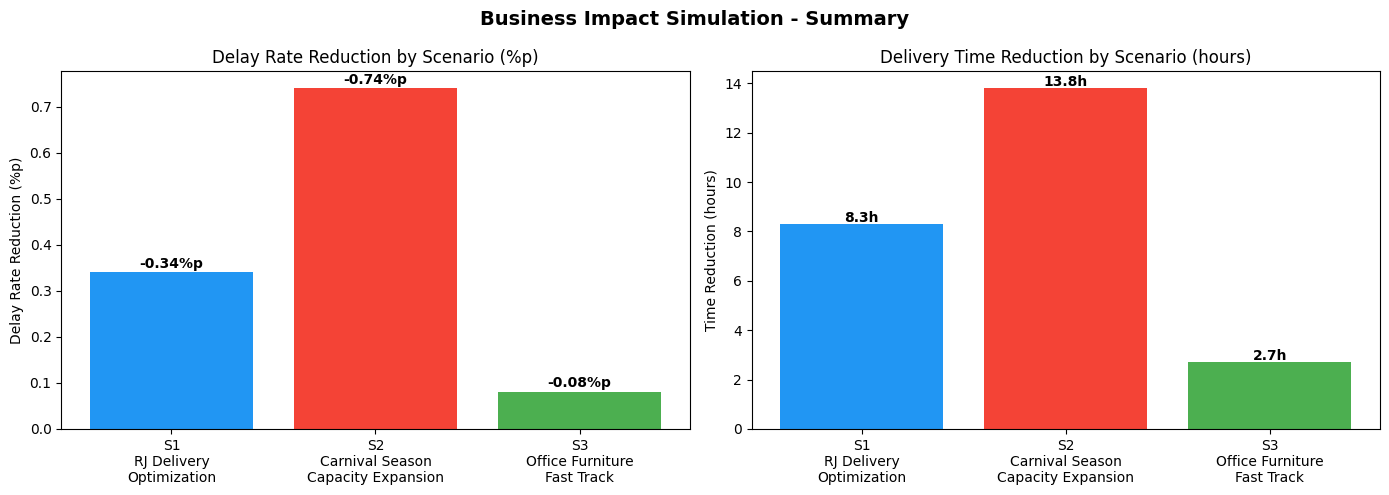


=== Improvement Priority ===
Priority 1: S2 Carnival Season Capacity Expansion (Delay Rate -0.74%p)
Priority 2: S1 RJ Delivery Optimization          (Delay Rate -0.34%p)
Priority 3: S3 Office Furniture Fast Track        (Delay Rate -0.08%p)

=== Key Insight ===
Root Cause의 설명력과 Business Impact는 다를 수 있다.

Seller Processing 단계에서는 Product Category가
가장 중요한 원인 변수(η²=12.8%)였으나,

전체 Lead Time의 74.2%를 차지하는 Carrier Delivery 단계의
개선이 최종 지연율 감소에 더 큰 영향을 미쳤다.


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# 최종 비교표 (Stage_improvement_pct 제외)
summary = {
    'Scenario': ['S1: RJ Delivery\nOptimization', 
                 'S2: Carnival Season\nCapacity Expansion', 
                 'S3: Office Furniture\nFast Track'],
    'Stage': ['Carrier Delivery', 'Carrier Delivery', 'Seller Processing'],
    'Reduction_hours': [8.3, 13.8, 2.7],
    'Delay_reduction': [0.34, 0.74, 0.08],
    'Priority': [2, 1, 3]
}

df_summary = pd.DataFrame(summary)

print("=== 7단계 최종 비교표 ===")
print(df_summary[['Scenario', 'Stage', 'Reduction_hours', 'Delay_reduction', 'Priority']]
      .sort_values('Priority')
      .to_string(index=False))

# 막대그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#F44336', '#4CAF50']
scenarios = ['S1\nRJ Delivery\nOptimization', 
             'S2\nCarnival Season\nCapacity Expansion', 
             'S3\nOffice Furniture\nFast Track']

# 그래프 1: 지연율 감소
axes[0].bar(scenarios, df_summary['Delay_reduction'], color=colors)
axes[0].set_title('Delay Rate Reduction by Scenario (%p)')
axes[0].set_ylabel('Delay Rate Reduction (%p)')
for i, v in enumerate(df_summary['Delay_reduction']):
    axes[0].text(i, v + 0.01, f'-{v}%p', ha='center', fontweight='bold')

# 그래프 2: 단축 시간
axes[1].bar(scenarios, df_summary['Reduction_hours'], color=colors)
axes[1].set_title('Delivery Time Reduction by Scenario (hours)')
axes[1].set_ylabel('Time Reduction (hours)')
for i, v in enumerate(df_summary['Reduction_hours']):
    axes[1].text(i, v + 0.1, f'{v}h', ha='center', fontweight='bold')

plt.suptitle('Business Impact Simulation - Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 우선순위
print("\n=== Improvement Priority ===")
print("Priority 1: S2 Carnival Season Capacity Expansion (Delay Rate -0.74%p)")
print("Priority 2: S1 RJ Delivery Optimization          (Delay Rate -0.34%p)")
print("Priority 3: S3 Office Furniture Fast Track        (Delay Rate -0.08%p)")

# 핵심 인사이트
print("\n=== Key Insight ===")
print("Root Cause의 설명력과 Business Impact는 다를 수 있다.")
print()
print("Seller Processing 단계에서는 Product Category가")
print("가장 중요한 원인 변수(η²=12.8%)였으나,")
print()
print("전체 Lead Time의 74.2%를 차지하는 Carrier Delivery 단계의")
print("개선이 최종 지연율 감소에 더 큰 영향을 미쳤다.")

In [9]:
# =================================================================
# S2: Carnival Season Capacity Expansion - A/B Test Design
# Baseline Calculation
# =================================================================

carnival = orders_customers[orders_customers['carrier_month'].isin([2, 3])]
delay_rate_carnival = (carnival['delivery_delay'] > 0).sum() / len(carnival) * 100
print(f"2~3월 Delay Rate: {delay_rate_carnival:.2f}%")

2~3월 Delay Rate: 15.14%


In [ ]:
from scipy import stats
from scipy.stats import norm
import numpy as np

# Power Analysis
# Baseline Delay Rate: 15.14%
# MDE: 0.74%p (시뮬레이션 예상 개선폭과 동일)
# alpha: 0.05
# power: 0.80

baseline = 0.1514
mde = 0.0074  # 0.74%p
target = baseline - mde  # 14.40%

alpha = 0.05
power = 0.80

z_alpha = norm.ppf(1 - alpha)
z_beta = norm.ppf(power)

p1 = baseline
p2 = target

numerator = (z_alpha * np.sqrt(2 * baseline * (1 - baseline)) + 
             z_beta * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
denominator = (p1 - p2) ** 2

sample_size = numerator / denominator

print(f"=== Power Analysis ===")
print(f"Baseline Delay Rate: {baseline*100:.2f}%")
print(f"Target Delay Rate: {target*100:.2f}%")
print(f"MDE: {mde*100:.2f}%p")
print(f"Alpha: {alpha}")
print(f"Power: {power}")
print(f"\n필요 샘플 수 (그룹당): {int(np.ceil(sample_size)):,}건")
print(f"필요 샘플 수 (전체): {int(np.ceil(sample_size * 2)):,}건")

=== Power Analysis ===
Baseline Delay Rate: 15.14%
Target Delay Rate: 14.40%
MDE: 0.74%p
Alpha: 0.05
Power: 0.8

필요 샘플 수 (그룹당): 28,812건
필요 샘플 수 (전체): 57,623건


: 

In [11]:
# 2~3월 일평균 주문 수 계산
carnival = orders_customers[orders_customers['carrier_month'].isin([2, 3])]
carnival['order_delivered_carrier_date'] = pd.to_datetime(carnival['order_delivered_carrier_date'])

daily_orders = carnival.groupby(carnival['order_delivered_carrier_date'].dt.date)['order_id'].count()
daily_avg = daily_orders.mean()

# 필요 실험 기간
required_sample = 126503
days_needed = required_sample / daily_avg

print(f"일평균 주문 수: {daily_avg:.0f}건")
print(f"필요 실험 기간: {days_needed:.0f}일 (약 {days_needed/7:.0f}주)")

일평균 주문 수: 175건
필요 실험 기간: 723일 (약 103주)
